📘 Notebook 1: Introduction to Tensors and Automatic Differentiation

MATH 6388 - Statistical and Machine Learning

Instructor: Farhad Pourkamali

# Tensors

*   Tensors are a specialized data structure that are very similar to vectors and matrices.

*   In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model's parameters.

*   Tensors are similar to NumPy’s ndarrays, except that tensors can run on GPUs or other hardware accelerators.

* When we refer to the dimension of a tensor, we mean the number of axes needed to identify an element, not the total number of values stored in the tensor.

<center>
<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/what-is-numpy.png?raw=true"
         height="250">
<center>


*   Let's start with importing PyTorch. The package is called `torch`, and we can check its version.



In [1]:
import torch

print("Using torch", torch.__version__)

Using torch 2.13.0


In [2]:
# 1D tensor
data1 = torch.tensor([4, -2, 7, 0, 5, 11])

# 2D tensor
data2 = torch.tensor([
    [1,  2,  3,  4],
    [5,  6,  7,  8],
    [9, 10, 11, 12]
])

In [3]:
print(data1)

tensor([ 4, -2,  7,  0,  5, 11])


In [5]:
print(data2)

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])


In [6]:
print(data1.shape, data2.shape)

torch.Size([6]) torch.Size([3, 4])


In [7]:
print("How many axes? ", data2.ndim)

How many axes?  2


In [8]:
print(type(data2))

<class 'torch.Tensor'>


In [9]:
data2.dtype

torch.int64

| Data Type       | Description              | Typical Use                                         |
| --------------- | ------------------------ | --------------------------------------------------- |
| `torch.int32`   | 32-bit integer           | General integer values                              |
| `torch.int64`   | 64-bit integer           | Indices and class labels (most common integer type) |
| `torch.float32` | 32-bit floating point    | **Default for deep learning**                       |
| `torch.float64` | 64-bit floating point    | Higher numerical precision                          |
| `torch.bool`    | Boolean (`True`/`False`) | Logical operations and masking                      |


In [10]:
x = torch.tensor([True, False, True])

print(x)
print(x.dtype)

tensor([ True, False,  True])
torch.bool


In [11]:
# you can use the .long() method, which is equivalent to converting to torch.int64

x.long()

tensor([1, 0, 1])

In [12]:
x.long().dtype

torch.int64

*   To access an element in a tensor, provide one index for each dimension to specify its location.

In [13]:
data2

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

In [14]:
# access 1st row of data2

data2[0]

tensor([1, 2, 3, 4])

In [15]:
data2[0].ndim

1


*   A 3D tensor can be viewed as a stack of 2D tensors, where each 2D tensor represents one layer of the 3D tensor.


<center>
<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/numpy3D.png?raw=true"
         height="300">
<center>

In [16]:
# 3D tensor
data3 = torch.tensor([
    [  # Layer 0 (index 0)
        [1, 2, 3],
        [4, 5, 6]
    ],

    [  # Layer 1 (index 1)
        [7, 8, 9],
        [10, 11, 12]
    ],

    [  # Layer 2 (index 2)
        [13, 14, 15],
        [16, 17, 18]
    ]
])

print(data3)
print("\n Shape:", data3.shape)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]],

        [[13, 14, 15],
         [16, 17, 18]]])

 Shape: torch.Size([3, 2, 3])


In [17]:
data3[1]

tensor([[ 7,  8,  9],
        [10, 11, 12]])

In [18]:
data3[1][0][2]

tensor(9)

In [19]:
data3[1,0,2]

tensor(9)

A higher-dimensional tensor can be viewed as a stack of lower-dimensional tensors.

*   1D tensor: a sequence of numbers.
*   2D tensor: a stack of 1D tensors.
*   3D tensor: a stack of 2D tensors.
*   ...and so on.

You can use `torch.stack` to concatenate a sequence of tensors along a new dimension: https://docs.pytorch.org/docs/2.12/generated/torch.stack.html

In [20]:
# Create three 2D tensors
layer0 = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

layer1 = torch.tensor([
    [7, 8, 9],
    [10, 11, 12]
])

layer2 = torch.tensor([
    [13, 14, 15],
    [16, 17, 18]
])

# Stack the 2D tensors to create a 3D tensor
data3 = torch.stack((layer0, layer1, layer2), dim=0)

print(data3)
print("\nShape:", data3.shape)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]],

        [[13, 14, 15],
         [16, 17, 18]]])

Shape: torch.Size([3, 2, 3])


✏️ Problem 1.1

Suppose a weather station records temperature, humidity, and wind speed every hour for 7 consecutive days. The data is stored in a PyTorch tensor, where:

- Axis 0 represents the day.
- Axis 1 represents the weather variable (0 = Temperature, 1 = Humidity, 2 = Wind Speed).
- Axis 2 represents the hour of the day (0–23).

```
# Generate random weather data
torch.manual_seed(42)
weather = torch.rand(7, 3, 24)
```

- What is the shape of the weather tensor?
- Print all weather measurements (temperature, humidity, and wind speed) for Day 4.
- Print the temperature recorded at 2:00 PM on Day 6.

In [4]:
# Brady's own code
torch.manual_seed(42)
weather = torch.rand(7, 3, 24)
axis_1_labels = {
    0: "Temperature",
    1: "Humidity",
    2: "Wind Speed"
}
print(f"1. Overall shape:\n{weather.shape}")
print(f"\n2. All measurement on Day 4:")
for i, measurements in enumerate(weather[3]):
    print(f"{axis_1_labels[i]} Measurements:")
    print(f"   {measurements}")
print(f"\n3. Temperature at 2pm on Day 6:\n{weather[5, 0, 12]}")
# print(weather[3])

1. Overall shape:
torch.Size([7, 3, 24])

2. All measurement on Day 4:
Temperature Measurements:
   tensor([0.5723, 0.3705, 0.7069, 0.3096, 0.1764, 0.8649, 0.2726, 0.3998, 0.0026,
        0.8346, 0.8788, 0.6822, 0.1514, 0.0065, 0.0939, 0.8729, 0.7401, 0.9208,
        0.7619, 0.6265, 0.4951, 0.1197, 0.0716, 0.0323])
Humidity Measurements:
   tensor([0.7047, 0.2545, 0.3994, 0.2122, 0.4089, 0.1481, 0.1733, 0.6659, 0.3514,
        0.8087, 0.3396, 0.1332, 0.4118, 0.2576, 0.3470, 0.0240, 0.7797, 0.1519,
        0.7513, 0.7269, 0.8572, 0.1165, 0.8596, 0.2636])
Wind Speed Measurements:
   tensor([0.6855, 0.9696, 0.4295, 0.4961, 0.3849, 0.0825, 0.7400, 0.0036, 0.8104,
        0.8741, 0.9729, 0.3821, 0.0892, 0.6124, 0.7762, 0.0023, 0.3865, 0.2003,
        0.4563, 0.2539, 0.2956, 0.3413, 0.0248, 0.9103])

3. Temperature at 2pm on Day 6:
0.2088828682899475


Functions such as `torch.ones_like()`, `torch.zeros_like()`, and `torch.rand_like()` create a new tensor with the same shape and data type (dtype) as the input tensor by default. These properties can be overridden if needed.

In [5]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print(x_data)

tensor([[1, 2],
        [3, 4]])


In [6]:
x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n {x_ones} \n")

x_ones = torch.zeros_like(x_data)
print(f"Zeros Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float32) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Zeros Tensor: 
 tensor([[0, 0],
        [0, 0]]) 

Random Tensor: 
 tensor([[0.8910, 0.7296],
        [0.1320, 0.2316]]) 



*   Attributes of a Tensor: Tensor attributes describe their shape, datatype, and the device on which they are stored.


In [39]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Tensor is stored on: cpu


* By default, PyTorch stores tensors on the CPU. If your computer has a supported hardware accelerator (such as an NVIDIA GPU or Apple Silicon GPU), you can move tensors to that device to perform computations more efficiently.

In [7]:
# Runtime > Change runtime type > GPU

import torch

# Get the current accelerator
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
    print(device)
else:
    device = "cpu"
    print("No accelerator available!")



mps


In [8]:
tensor = torch.rand(3, 4)

# Move the tensor to the selected device
tensor = tensor.to(device)

print(f"Tensor is stored on: {tensor.device}")

Tensor is stored on: mps:0


Operations on Tensors

Over 1200 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more are comprehensively described here: https://docs.pytorch.org/docs/2.12/torch.html.

Each of these operations can be run on the CPU and Accelerator such as CUDA and MPS. If you are using Colab, allocate an accelerator by going to Runtime > Change runtime type > GPU.

The simplest operation is to add two tensors.

In [42]:
x1 = torch.rand(2, 3)
x2 = torch.rand(2, 3)
y = x1 + x2

print("X1", x1)
print("\nX2", x2)
print("\nY= X1+X2", y)

X1 tensor([[0.4360, 0.9751, 0.8359],
        [0.4812, 0.0297, 0.5219]])

X2 tensor([[0.1595, 0.9066, 0.1965],
        [0.4639, 0.3890, 0.5890]])

Y= X1+X2 tensor([[0.5955, 1.8817, 1.0324],
        [0.9451, 0.4188, 1.1109]])


Calling `x1 + x2` creates a new tensor containing the sum of the two inputs.

In [43]:
print(x1)

tensor([[0.4360, 0.9751, 0.8359],
        [0.4812, 0.0297, 0.5219]])


*   However, we can also use `in-place operations` that are applied directly on the memory of a tensor.

* In-place operations are usually marked with a underscore postfix (e.g. “add_” instead of “add”).

In [44]:
x1.add_(x2)

tensor([[0.5955, 1.8817, 1.0324],
        [0.9451, 0.4188, 1.1109]])

In [45]:
x1

tensor([[0.5955, 1.8817, 1.0324],
        [0.9451, 0.4188, 1.1109]])

Sometimes, we need to change the shape of a tensor without changing its data. The `view()` method returns a new view of the tensor with a different shape.

In [46]:
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

print("Original tensor:","\n", x)

# Reshape to a 1D tensor
print(x.view(6))

# Reshape to a (3, 2) tensor
print(x.view(3, 2))

Original tensor: 
 tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([1, 2, 3, 4, 5, 6])
tensor([[1, 2],
        [3, 4],
        [5, 6]])


PyTorch can automatically infer one of the dimensions by using -1.

In [47]:
x = torch.arange(12)

print(x.view(3, -1))

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


The `reshape()` method can also be used to reshape tensors and is generally the recommended choice in modern PyTorch.

In [48]:
x = torch.arange(12)

print(x.reshape(3, -1))

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


PyTorch provides several functions for matrix multiplication. The most common are `torch.matmul()`, `torch.mm()`, and `torch.bmm()`.

| Function         | Input                                            | Description                                             |
| ---------------- | ------------------------------------------------ | ------------------------------------------------------- |
| `torch.matmul()` | Vectors, matrices, or higher-dimensional tensors | **General-purpose** matrix multiplication |
| `torch.mm()`     | Two 2D matrices                                  | Matrix multiplication for 2D tensors only               |
| `torch.bmm()`    | Two batches of 3D tensors                        | Batch matrix multiplication                             |


In [53]:
A = torch.tensor([
    [1, 2],
    [3, 4]
])

B = torch.tensor([
    [5, 6],
    [7, 8]
])

C1 = torch.matmul(A, B)

print(C1)

tensor([[19, 22],
        [43, 50]])


In [54]:
C2 = torch.mm(A, B)

print(C2)

tensor([[19, 22],
        [43, 50]])


In [56]:
# Batch of two 2×2 matrices
A = torch.tensor([
    [[1, 2],
     [0, 1]],

    [[2, 0],
     [1, 3]]
])

# Another batch of two 2×2 matrices
B = torch.tensor([
    [[1, 0],
     [2, 1]],

    [[1, 2],
     [0, 1]]
])

# Batch matrix multiplication
C = torch.bmm(A, B)

print(C)
print("\nShape:", C.shape)

tensor([[[5, 2],
         [2, 1]],

        [[2, 4],
         [1, 5]]])

Shape: torch.Size([2, 2, 2])


In [57]:
A[0] @ B[0]

tensor([[5, 2],
        [2, 1]])

In [58]:
A[1] @ B[1]

tensor([[2, 4],
        [1, 5]])

The dot product multiplies the corresponding elements of two 1D tensors and then sums the results. It is one of the most fundamental operations in linear algebra and machine learning.

*   The two tensors must have the same number of elements.
*   The result of a dot product is a single scalar value.
*   In the following example, we have

(1×4)+(2×5)+(3×6)=4+10+18=32

In [59]:
x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

z = torch.dot(x, y)

print(z)

tensor(32)


✏️ Problem 1.2

Recall that the angle $\theta$ between two vectors $\mathbf{x}$ and $\mathbf{y}$ is given by

$$
\cos(\theta)=
\frac{\mathbf{x}\cdot\mathbf{y}}
{\|\mathbf{x}\|\,\|\mathbf{y}\|}
$$

where:

- $\mathbf{x}\cdot\mathbf{y}$ is the dot product of the vectors.
- $\|\mathbf{x}\|$ and $\|\mathbf{y}\|$ are their Euclidean (L2) norms.

Write a Python function named `vector_angle()` that computes the angle (in degrees) between two 1D PyTorch tensors.

```
# Example
x = torch.tensor([0.0, 1.0])
y = torch.tensor([-1.0, 1.0])

angle = vector_angle(x, y)

print(f"Angle: {angle:.2f} degrees")
```

In [9]:
from torch import linalg as LA

def vector_angle(
        x: torch.Tensor,
        y: torch.Tensor
) -> torch.Tensor:
    xdoty = torch.dot(x, y)
    xnorm = LA.vector_norm(x)
    ynorm = LA.vector_norm(y)
    cos_theta = xdoty / (xnorm * ynorm)
    radians = torch.acos(cos_theta)
    
    return torch.rad2deg(radians)
    
x = torch.tensor([0.0, 1.0])
y = torch.tensor([-1.0, 1.0])
angle = vector_angle(x, y)
print(f"Angle: {angle:.2f} degrees")

Angle: 45.00 degrees


`torch.permute()` rearranges the order of a tensor's dimensions (axes) without changing its underlying data.

PyTorch and many computer vision libraries store color images as tensors with shape

(Channels, Height, Width)

However, Matplotlib expects the image to have the shape

(Height, Width, Channels)

We download an image, convert it to a PyTorch tensor, and display it using Matplotlib.

In [10]:
import torch
import matplotlib.pyplot as plt
from torchvision.io import decode_image
from urllib.request import urlretrieve # downloads a file from a URL and saves it to your local computer

# Code I copied to fix a 'ssl-certificate-verify-failed' error -Brady
# Source - https://stackoverflow.com/a/49174340
# Posted by Jia, modified by community. See post 'Timeline' for change history
# Retrieved 2026-08-18, License - CC BY-SA 4.0
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Download an image
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

urlretrieve(url, "dog.jpg") # The second argument is the filename (or path)

# # Read the image
image = decode_image("dog.jpg")

print("Original shape:", image.shape)

Original shape: torch.Size([3, 1213, 1546])


In [11]:
image_new = image.permute(1,2,0)

print("New shape:", image_new.shape)

New shape: torch.Size([1213, 1546, 3])



      (C, H, W)  ───────────────▶  (H, W, C)
       0  1  2                     1  2  0

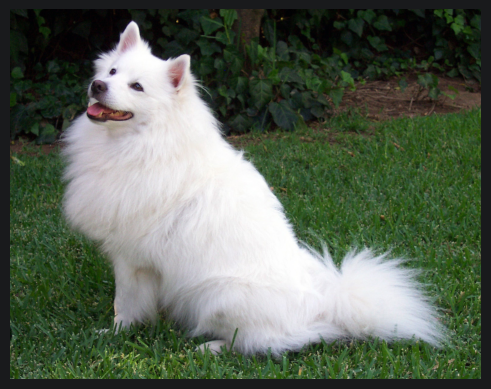

In [12]:
plt.imshow(image_new)
plt.axis("off")
plt.show()

GPUs can make tensor computations much faster because:

*   GPUs contain many small cores, allowing them to perform many operations in parallel.
*   Tensor operations often involve repeated arithmetic, such as matrix multiplication, which is highly parallelizable.
*   Deep learning models rely heavily on large matrix operations, so GPUs are especially useful for training neural networks.
*   For small tensors, the CPU may be faster because moving data to and from the GPU has overhead.



In [8]:
import torch
import time
import pandas as pd

# Determine the available accelerator
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
    print(f"Using accelerator: {device}")
else:
    device = torch.device("cpu")
    print("No hardware accelerator detected. Using CPU.")

# Matrix sizes
sizes = [10000, 20000, 30000]

results = []

for n in sizes:
    print(f"Running n = {n}")

    # Create a random matrix on the CPU
    A_cpu = torch.rand(n, n)

    # ---------------- CPU Timing ----------------
    start = time.perf_counter()
    C_cpu = torch.matmul(A_cpu, A_cpu)
    cpu_time = time.perf_counter() - start

    # ---------------- Accelerator Timing ----------------
    accel_time = None

    if torch.accelerator.is_available():

        A = A_cpu.to(device)

        # Warm-up
        _ = torch.matmul(A, A)
        torch.accelerator.synchronize()

        start = time.perf_counter()
        C = torch.matmul(A, A)
        torch.accelerator.synchronize() # Wait for all kernels on the given device to complete
        accel_time = time.perf_counter() - start

        # Compute speedup
        speedup = cpu_time / accel_time

    results.append([n, cpu_time, accel_time, speedup])

# Display results
df = pd.DataFrame(results,
                  columns=["Matrix Size", "CPU Time (s)", "Accelerator Time (s)", "Speedup (×)"])

print(df)

Using accelerator: mps
Running n = 10000
Running n = 20000
Running n = 30000
   Matrix Size  CPU Time (s)  Accelerator Time (s)  Speedup (×)
0        10000      2.211546              2.079982     1.063253
1        20000     18.117484             12.947110     1.399346
2        30000     71.420370             54.982677     1.298961


# Computation Graphs and Automatic Differentiation (Autodiff)



*   One of the main reasons for using PyTorch in Deep Learning projects is that we can automatically get gradients/derivatives of functions that we define.
*   Manual differentiation works well for simple functions, but modern deep learning models may contain millions or even billions of parameters. Computing derivatives by hand quickly becomes impossible.
*   Suppose we define the function

$$
f(x_1,x_2)=x_1^2x_2+x_2+2.
$$

Since this function has two input variables, it has two partial derivatives

$$
\frac{\partial f}{\partial x_1},
\qquad
\frac{\partial f}{\partial x_2}.
$$

These partial derivatives are combined into the gradient vector

$$
\nabla f(x_1,x_2)=
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2}
\end{bmatrix}.
$$

More generally, if a function has $n$ input variables,

$$
f(x_1,x_2,\ldots,x_n),
$$

its gradient is

$$
\nabla f=
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}.
$$



## Step 1: Manual Differentiation

Recall that our function is

$$
f(x_1,x_2)=x_1^2x_2+x_2+2.
$$

First, compute the partial derivative with respect to $x_1$ while treating $x_2$ as a constant:

$$
\frac{\partial f}{\partial x_1}
=
2x_1x_2.
$$

Next, compute the partial derivative with respect to $x_2$ while treating $x_1$ as a constant:

$$
\frac{\partial f}{\partial x_2}
=
x_1^2+1.
$$

Combining these partial derivatives gives the gradient vector:

$$
\nabla f(x_1,x_2)
=
\begin{bmatrix}
\dfrac{\partial f}{\partial x_1} \\
\dfrac{\partial f}{\partial x_2}
\end{bmatrix}
=
\begin{bmatrix}
2x_1x_2 \\
x_1^2+1
\end{bmatrix}.
$$

Now evaluate the gradient at

$$
x_1=3,
\qquad
x_2=4.
$$

The partial derivatives become

$$
\frac{\partial f}{\partial x_1}
=
24,
$$

and

$$
\frac{\partial f}{\partial x_2}
=
10.
$$

Therefore,

$$
\nabla f
=
\begin{bmatrix}
24 \\
10
\end{bmatrix}.
$$

## Step 2: Computation Graph

Instead of viewing the function as one large equation, PyTorch breaks it into a sequence of simple operations.

This sequence is called a computation graph, where each node represents an elementary mathematical operation.

For our function

$$
f(x_1,x_2)=x_1^2x_2+x_2+2,
$$

we define several intermediate variables:

$$
u_1=x_1^2,
$$

$$
u_2=u_1x_2,
$$

$$
u_3=u_2+x_2,
$$

$$
f=u_3+2.
$$

The computation graph is therefore


<center>
<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/computationgraph.png?raw=true"
         height="320">
<center>

## Step 3: Applying the Chain Rule

Once the forward pass is complete, PyTorch computes gradients by traversing the computation graph **backwards**. This process is called **backpropagation** or **reverse-mode automatic differentiation**.

The key mathematical tool is the **chain rule**.

Starting from the output,

$$
\frac{\partial f}{\partial f}=1,
$$

we work backwards through the graph.

Since

$$
f=u_3+2,
$$

we have

$$
\frac{\partial f}{\partial u_3}=1.
$$

Next,

$$
u_3=u_2+x_2,
$$

so

$$
\frac{\partial u_3}{\partial u_2}=1,
\qquad
\frac{\partial u_3}{\partial x_2}=1.
$$

Applying the chain rule,

$$
\frac{\partial f}{\partial u_2}
=
\frac{\partial f}{\partial u_3}
\frac{\partial u_3}{\partial u_2}
=
1.
$$

Next,

$$
u_2=u_1x_2,
$$

whose local derivatives are

$$
\frac{\partial u_2}{\partial u_1}=x_2,
\qquad
\frac{\partial u_2}{\partial x_2}=u_1.
$$

Therefore,

$$
\frac{\partial f}{\partial u_1}
=
\frac{\partial f}{\partial u_2}
\frac{\partial u_2}{\partial u_1}
=
x_2.
$$

Finally,

$$
u_1=x_1^2,
$$

so

$$
\frac{\partial u_1}{\partial x_1}=2x_1.
$$

Applying the chain rule one last time,

$$
\frac{\partial f}{\partial x_1}
=
\frac{\partial f}{\partial u_1}
\frac{\partial u_1}{\partial x_1}
=
x_2(2x_1)
=
2x_1x_2.
$$

Notice that $x_2$ influences the output through **two different paths** in the graph:


Therefore, both contributions must be added together,

$$
\frac{\partial f}{\partial x_2} = \frac{\partial f}{\partial u_3}
\frac{\partial u_3}{\partial x_2}+ \frac{\partial f}{\partial u_2}
\frac{\partial u_2}{\partial x_2}
=
1+u_1
=
1+x_1^2.
$$

These are exactly the same gradients we computed manually:

$$
\nabla f(x_1,x_2)
=
\begin{bmatrix}
2x_1x_2\\
x_1^2+1
\end{bmatrix}.
$$

In [1]:
import torch

# Define the input vector
x = torch.tensor([3.0, 4.0], requires_grad=True)


# Define the function
f = x[0]**2 * x[1] + x[1] + 2

# Compute the gradient
f.backward()

# Print the gradient
print(f"Gradient: {x.grad}")

Gradient: tensor([24., 10.])


In [2]:
# Define the input vector
x = torch.tensor([3.0, 4.0], requires_grad=True)

# Define the function
f = x[0]**2 * x[1] + x[1] + 2

# Print the gradient (it is None by default)
print(f"Gradient: {x.grad}")

Gradient: None


## From Autodiff to Linear Regression

Now that we understand how PyTorch computes gradients, let us connect this idea to one of the simplest machine learning models: univariate linear regression.

In univariate linear regression, we assume that the output can be predicted from one input variable using a linear function

$$
\hat{y} = w_0+w_1x
$$

Here:

- $x$ is the input feature,
- $\hat{y}$  is the predicted output,
- $w_0$ is the intercept or bias term,
- $w_1$ is the slope or weight.

Given a training dataset containing $n$ input-output pairs,

$$
(x_1,y_1),\;
(x_2,y_2),\;
\ldots,\;
(x_n,y_n),
$$

our linear regression model predicts

$$
\hat{y}_i=w_0+w_1x_i.
$$

A standard loss function for regression problems is the Mean Squared Error (MSE), which measures the average squared difference between the predicted and true target values:

$$
L(w_0,w_1)
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\hat{y}_i-y_i
\right)^2.
$$

<center>
<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/univariatelinear.png?raw=true"
         height="300">
<center>

Notice that the loss depends on the model parameters $w_0$ and $w_1$. Our goal is to find the values of these parameters that minimize the loss.

To accomplish this, we compute the gradient of the loss with respect to the model parameters,

$$
\nabla L(w_0,w_1)
=
\begin{bmatrix}
\dfrac{\partial L}{\partial w_0}\\[6pt]
\dfrac{\partial L}{\partial w_1}
\end{bmatrix},
$$

which tells us how the loss changes when each parameter is modified.

Rather than deriving these partial derivatives manually, we will use PyTorch's Automatic Differentiation to compute them automatically.

Define the parameter vector

$$
\mathbf{w}
=
\begin{bmatrix}
w_0\\
w_1
\end{bmatrix}.
$$

The gradient of the loss can now be written as

$$
\nabla L(\mathbf{w})
=
\begin{bmatrix}
\dfrac{\partial L}{\partial w_0}\\[6pt]
\dfrac{\partial L}{\partial w_1}
\end{bmatrix}.
$$

Once the gradient has been computed, **gradient descent** updates the parameter vector according to

$$
\mathbf{w}
\leftarrow
\mathbf{w}
-
\eta
\nabla L(\mathbf{w}),
$$

where $\eta>0$ is the learning rate, which controls the size of each update.

<center>
<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/deriv.png?raw=true"
         height="250">
<center>

## Gradient Descent in One Dimension: Theoretical Justification

Suppose we have a loss function

$$
L(w),
$$

where $w$ is a single parameter. Our goal is to solve the optimization problem

$$
\arg\min_w L(w).
$$

In calculus, one approach is to solve

$$
\frac{dL}{dw}=0,
$$

to find the critical points of the function. However, for many machine learning problems, solving this equation exactly is either difficult or impossible.

Instead, we use an iterative optimization algorithm. Suppose our current estimate of the parameter is $w$. We improve this estimate by taking a small step,

$$
w_{\text{new}}
=
w+\Delta w.
$$

The question is: **How should we choose** $\Delta w$?

To answer this, consider the first-order Taylor approximation

$$
L(w+\Delta w)
\approx
L(w)
+
\frac{dL}{dw}\Delta w.
$$

Now choose the update direction to be

$$
\Delta w
=
-\eta\frac{dL}{dw},
$$

where $\eta>0$.

Substituting this into the Taylor approximation gives

$$
\begin{aligned}
L(w+\Delta w)
&\approx
L(w)
+
\frac{dL}{dw}
\left(
-\eta\frac{dL}{dw}
\right)\\[6pt]
&=
L(w)
-
\eta
\left(
\frac{dL}{dw}
\right)^2.
\end{aligned}
$$

This is the key observation. Consider the second term in the Taylor approximation.

If

$$
\frac{dL(w)}{dw}=0,
$$

then

$$
\left(\frac{dL(w)}{dw}\right)^2=0,
$$

which means that we have reached a **critical point**. We can then determine whether this point is a local minimum by examining the second derivative or other properties of the function.

On the other hand, if

$$
\frac{dL(w)}{dw}\neq0,
$$

then

$$
\left(\frac{dL(w)}{dw}\right)^2>0.
$$

Therefore,

$$
L(w+\Delta w)
\approx
L(w)
-
\eta
\left(
\frac{dL(w)}{dw}
\right)^2
<
L(w),
$$

provided that the learning rate $\eta$ is sufficiently small so that the higher-order terms in the Taylor approximation are negligible.

*   Let us return to our univariate linear regression model and implement it from scratch.

<center>
<img src="https://github.com/farhad-pourkamali/MATH6388Updated/blob/main/Images/univariatelinear.png?raw=true"
         height="300">
<center>



*   Notice that the implementation contains several important statements:

```
with torch.no_grad():
    self.w -= self.learning_rate * self.w.grad
```
The `torch.no_grad()` context temporarily disables gradient tracking. The parameter update is part of the optimization algorithm; it is not a mathematical operation that should become part of the computational graph.

*   After updating the parameters, we also execute

```
self.w.grad.zero_()
```

PyTorch accumulates gradients by default. This means that every time we call `loss.backward()`, the newly computed gradients are added to the existing values stored in `self.w.grad`. Since gradient descent requires only the gradients from the current iteration, we reset them to zero before the next forward and backward pass. Failing to do so would cause gradients from previous iterations to accumulate, resulting in incorrect parameter updates.

* The function `torch.as_tensor()` converts its input into a PyTorch tensor. If the input is already a tensor, it returns the same tensor without making an unnecessary copy. If the input is a list, NumPy array, or another compatible object, it creates a tensor from that data.

In [3]:
import torch

class UnivariateLinearRegression:
    def __init__(self, learning_rate=0.01, num_epochs=1000):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs

        # Initialize parameters randomly
        self.w0 = torch.randn(1, requires_grad=True)
        self.w1 = torch.randn(1, requires_grad=True)

    def fit(self, x, y):
        x = torch.as_tensor(x, dtype=torch.float32)
        y = torch.as_tensor(y, dtype=torch.float32)

        for epoch in range(self.num_epochs):

            # Forward pass
            y_hat = self.w0 + self.w1 * x

            # Compute MSE loss
            loss = torch.mean((y_hat - y) ** 2)

            # Compute gradients
            loss.backward()

            # Gradient descent update
            with torch.no_grad():
                self.w0 -= self.learning_rate * self.w0.grad
                self.w1 -= self.learning_rate * self.w1.grad

            # Reset gradients
            self.w0.grad.zero_()
            self.w1.grad.zero_()

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss = {loss.item():.4f}")

    def predict(self, x):
        x = torch.as_tensor(x, dtype=torch.float32)

        with torch.no_grad():
            return self.w0 + self.w1 * x

In [4]:
# For reproducibility
torch.manual_seed(42)

# Generate inputs
# Brady notes: Create a tensor of length 50 that moves from 0 to 10 in identically spaced increments
x = torch.linspace(0, 10, 50)

# True parameters
w0_true = 3.0
w1_true = 2.0

# Generate targets with a small amount of Gaussian noise
y = w0_true + w1_true * x + 0.5 * torch.randn_like(x)

In [7]:
print(f"x: \n{x}\ny: \n{y}")

x: 
tensor([ 0.0000,  0.2041,  0.4082,  0.6122,  0.8163,  1.0204,  1.2245,  1.4286,
         1.6327,  1.8367,  2.0408,  2.2449,  2.4490,  2.6531,  2.8571,  3.0612,
         3.2653,  3.4694,  3.6735,  3.8776,  4.0816,  4.2857,  4.4898,  4.6939,
         4.8980,  5.1020,  5.3061,  5.5102,  5.7143,  5.9184,  6.1224,  6.3265,
         6.5306,  6.7347,  6.9388,  7.1429,  7.3469,  7.5510,  7.7551,  7.9592,
         8.1633,  8.3673,  8.5714,  8.7755,  8.9796,  9.1837,  9.3878,  9.5918,
         9.7959, 10.0000])
y: 
tensor([ 3.9635,  4.1518,  4.2667,  3.1717,  4.9719,  4.4235,  5.4274,  5.0548,
         5.8892,  7.4978,  6.8854,  6.7880,  7.5340,  8.0264,  8.3299,  9.5037,
        10.3518,  9.8590, 10.0982, 10.9749, 10.7842, 12.1106, 12.3800, 13.2281,
        13.4355, 13.8523, 13.9175, 14.6878, 14.3128, 14.8576, 15.1191, 16.0830,
        15.3689, 16.0338, 16.9166, 17.5486, 17.4499, 18.6977, 18.1032, 18.5504,
        18.9080, 19.2735, 20.1111, 20.8888, 20.9103, 22.2896, 21.1832, 22.8754,
     

In [8]:
model = UnivariateLinearRegression(
    learning_rate=0.01,
    num_epochs=1000
)

print(f"Initial w0 = {model.w0.item():.3f}")
print(f"Initial w1 = {model.w1.item():.3f}")

model.fit(x, y)

print(f"Estimated w0 = {model.w0.item():.3f}")
print(f"Estimated w1 = {model.w1.item():.3f}")

print(f"True w0 = {w0_true}")
print(f"True w1 = {w1_true}")

Initial w0 = -0.569
Initial w1 = 1.258
Epoch    0 | Loss = 58.6934
Epoch  100 | Loss = 1.3791
Epoch  200 | Loss = 0.6734
Epoch  300 | Loss = 0.4165
Epoch  400 | Loss = 0.3230
Epoch  500 | Loss = 0.2890
Epoch  600 | Loss = 0.2766
Epoch  700 | Loss = 0.2720
Epoch  800 | Loss = 0.2704
Epoch  900 | Loss = 0.2698
Estimated w0 = 3.037
Estimated w1 = 2.001
True w0 = 3.0
True w1 = 2.0


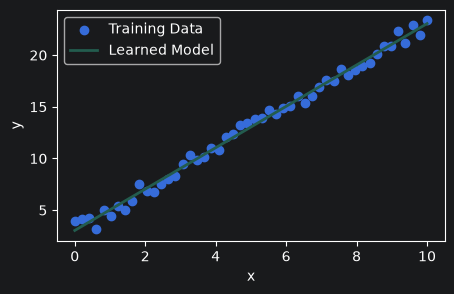

In [9]:
import matplotlib.pyplot as plt

y_pred = model.predict(x)

plt.figure(figsize=(5,3))
plt.scatter(x, y, label="Training Data")
plt.plot(x, y_pred, "C6", linewidth=2, label="Learned Model")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

✏️ Problem 1.3

In the implementation of `UnivariateLinearRegression`, locate the following two lines inside the `fit()` method:

`self.w0.grad.zero_()`
`self.w1.grad.zero_()`

Comment out (or remove) these two lines and run the same training example from the notebook. Plot or record the training loss over the epochs. Explain why the optimization behaves differently.

✏️ Problem 1.4

In this problem, you will apply your implementation of gradient descent to a real-world dataset. Use the correct implementation of the `UnivariateLinearRegression` class from the previous section (the version that correctly calls `zero_()` to clear the gradients after each parameter update).

Use the Credit dataset provided with this notebook.

- Input feature: Rating
- Target variable: Balance

Train your UnivariateLinearRegression model using the training data. Use the trained model to predict the balances for the testing data. Create a scatter plot comparing the actual and predicted balance values on the testing set.

- The x-axis labeled Actual Balance.
- The y-axis labeled Predicted Balance.
- A scatter plot of the test samples.
- A 45-degree reference line (i.e., (y=x)) to indicate perfect predictions.




In [ ]:
url = "https://raw.githubusercontent.com/farhad-pourkamali/MATH6388Updated/refs/heads/main/Data/Credit.csv"
data = pd.read_csv(url, index_col=0)

# 1. Extract raw numpy arrays
x_train_raw = data["Rating"][:200].to_numpy()
x_test_raw  = data["Rating"][200:].to_numpy()

y_train = data["Balance"][:200].to_numpy()
y_test  = data["Balance"][200:].to_numpy()

# 2. Normalize X features using training set parameters
# (This scales X values to a manageable 0 to 1 range)
x_min = x_train_raw.min()
x_max = x_train_raw.max()

x_train = (x_train_raw - x_min) / (x_max - x_min)
x_test  = (x_test_raw - x_min) / (x_max - x_min)

# 3. Train the model


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.7)

# 45-degree reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--',
         linewidth=2,
         label='Perfect Prediction')

plt.xlabel("Actual Balance")
plt.ylabel("Predicted Balance")
plt.legend()
plt.grid(True)

plt.show()

✏️ Problem 1.5

One of the most useful methods in PyTorch is `.detach()`, which creates a new tensor that shares the same numerical values as the original tensor but is detached from the computation graph. In other words, PyTorch treats the detached tensor as a constant during backpropagation, so gradients are not propagated through the operations that produced it.

In this problem, you will investigate how .detach() affects both the computation graph and the gradients computed by PyTorch.

Let

$$
z = \log(w)
$$

and define the loss function

$$
L = w^2 z.
$$

Assume

```
w = torch.tensor(2.0, requires_grad=True)
```

Part A: Without .detach()

Consider the following code:

```
import torch

w = torch.tensor(2.0, requires_grad=True)

z = torch.log(w)
loss = w**2 * z

loss.backward()
```

Compute $\frac{dL}{dw}$ by hand and run the code and verify that the gradient matches your calculation.

Part B: With .detach()

Now modify the code as follows:

```
import torch

w = torch.tensor(2.0, requires_grad=True)

z = torch.log(w).detach()
loss = w**2 * z

loss.backward()
```
Compute $\frac{dL}{dw}$ by hand and run the code and compare the gradient with your prediction.
